In [54]:
import pandas as pd
df = pd.read_csv("car_price_dataset.csv")
df

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
...,...,...,...,...,...,...,...,...,...,...
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084


The Car Price Dataset contains detailed information about various used cars, including attributes that influence their resale value. The goal of analyzing this dataset is to understand how different features affect car prices and to potentially build predictive models.
-**Purpose of the Dataset**
-> To explore factors influencing car price.
-> To build predictive models that estimate the price of a car based on its attributes.
-> To visualize trends in the automotive market (e.g., fuel preferences, age of cars).
-> To aid buyers and sellers in understanding market value.

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  object 
 1   Model         10000 non-null  object 
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  object 
 5   Transmission  10000 non-null  object 
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


In [56]:
df.head(20)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
5,Toyota,Camry,2007,2.7,Petrol,Automatic,157889,4,4,7242
6,Honda,Civic,2010,3.4,Electric,Automatic,139584,3,1,11208
7,Kia,Sportage,2001,4.7,Electric,Semi-Automatic,157495,2,2,7950
8,Kia,Sportage,2014,2.6,Hybrid,Manual,98700,3,4,9926
9,Toyota,RAV4,2005,3.1,Petrol,Manual,107724,2,5,6545


In [57]:
df.isnull().sum()

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

In [58]:
df['Model'].value_counts()

Model
Accord      365
Fiesta      363
Impala      355
5 Series    353
Tiguan      352
Focus       351
Q5          350
A4          350
Elantra     347
Golf        339
A3          338
Optima      336
Civic       336
3 Series    335
Explorer    334
Malibu      333
Tucson      329
Passat      329
Rio         327
Corolla     325
RAV4        324
Camry       321
E-Class     321
Sonata      319
Equinox     315
GLA         315
Sportage    313
X5          311
CR-V        308
C-Class     306
Name: count, dtype: int64

In [59]:
df['Brand'].value_counts()

Brand
Ford          1048
Audi          1038
Volkswagen    1020
Honda         1009
Chevrolet     1003
BMW            999
Hyundai        995
Kia            976
Toyota         970
Mercedes       942
Name: count, dtype: int64

In [60]:
df['Price'].value_counts()

Price
2000     93
8217      7
9189      7
8630      6
9498      6
         ..
6687      1
14954     1
10272     1
4214      1
3342      1
Name: count, Length: 6661, dtype: int64

In [61]:
df['Year'].value_counts()

Year
2002    462
2011    449
2023    448
2012    437
2017    433
2010    431
2005    431
2007    430
2015    426
2018    425
2013    422
2019    421
2014    417
2006    415
2020    415
2001    406
2009    399
2022    397
2016    395
2004    394
2000    393
2021    391
2008    382
2003    381
Name: count, dtype: int64

In [62]:
df['Doors'].value_counts()

Doors
3    2575
4    2514
5    2456
2    2455
Name: count, dtype: int64

In [63]:
df['Owner_Count'].value_counts()

Owner_Count
5    2036
1    2036
2    2020
3    1977
4    1931
Name: count, dtype: int64

In [64]:
df[df["Year"] == 2009]['Brand'].value_counts()

Brand
Honda         52
Chevrolet     46
Volkswagen    44
Hyundai       40
Mercedes      40
Kia           39
Audi          38
BMW           36
Ford          35
Toyota        29
Name: count, dtype: int64

In [65]:
df[df["Year"] == 2009]['Owner_Count'].value_counts()

Owner_Count
1    92
2    85
4    79
5    76
3    67
Name: count, dtype: int64

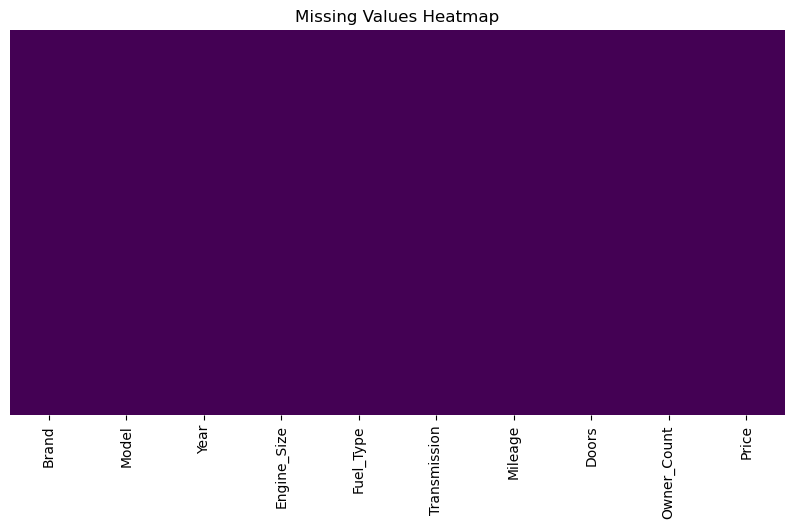

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

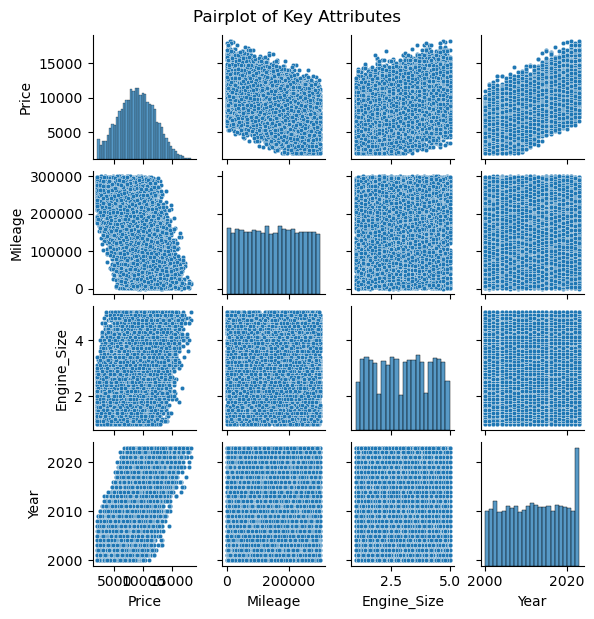

In [67]:
selected_columns = ["Price", "Mileage", "Engine_Size", "Year"]

# Creating a pairplot with smaller size
sns.pairplot(df[selected_columns], height=1.5, plot_kws={'s': 10}, diag_kind='hist')

# Adding a title
plt.suptitle("Pairplot of Key Attributes", y=1.02)
plt.show()

The Seaborn pairplot showing relationships between four key numerical attributes from the Car Price Dataset

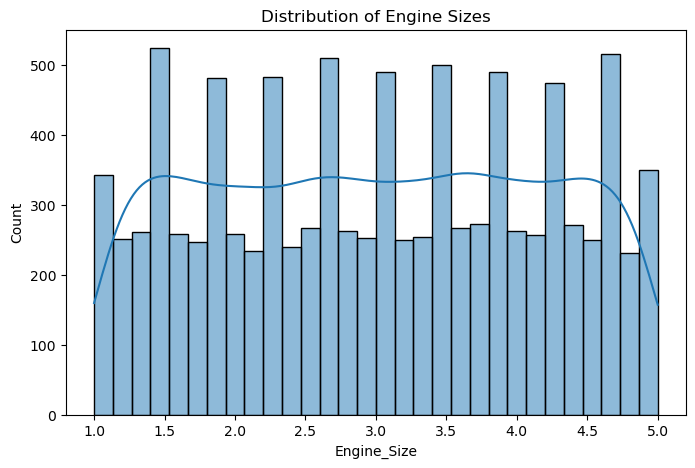

In [68]:
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
sns.histplot(df["Engine_Size"], bins=30, kde=True, ax=axes)
axes.set_title("Distribution of Engine Sizes")
plt.show()

This is a distribution plot of Engine Sizes in the car dataset

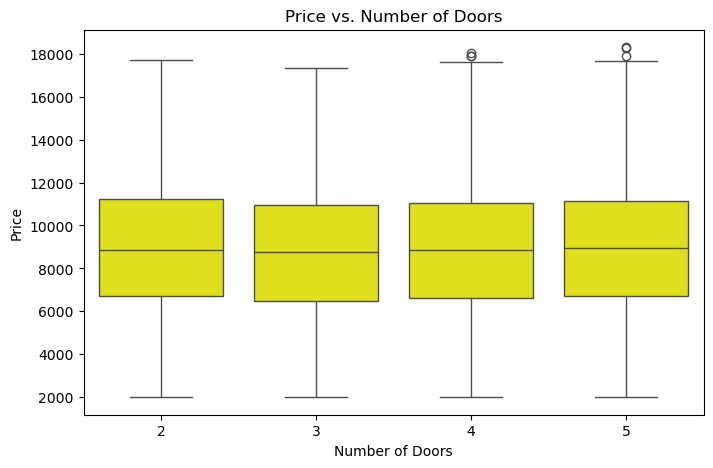

In [69]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Doors"], y=df["Price"],color="yellow")
plt.title("Price vs. Number of Doors")
plt.xlabel("Number of Doors")
plt.ylabel("Price")
plt.show()

This box plot shows the relationship between car price and the number of doors, and it's a helpful way to compare price distribution across different car body styles.

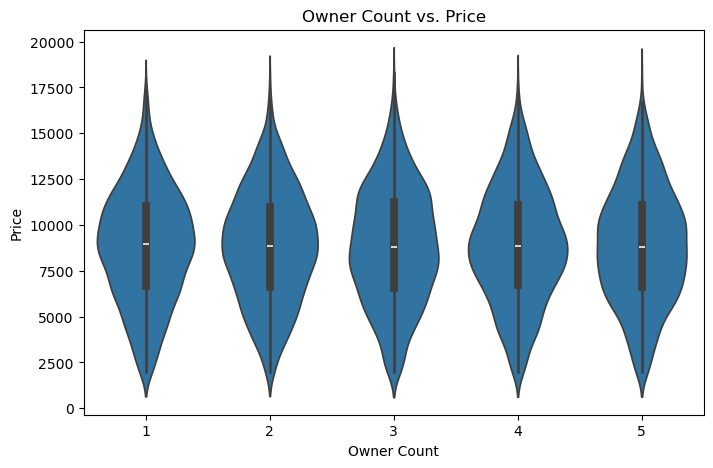

In [70]:
plt.figure(figsize=(8, 5))
sns.violinplot(x=df["Owner_Count"], y=df["Price"])
plt.title("Owner Count vs. Price")
plt.xlabel("Owner Count")
plt.ylabel("Price")
plt.show()

This violin plot shows the relationship between the number of previous owners and the price of cars in the dataset.

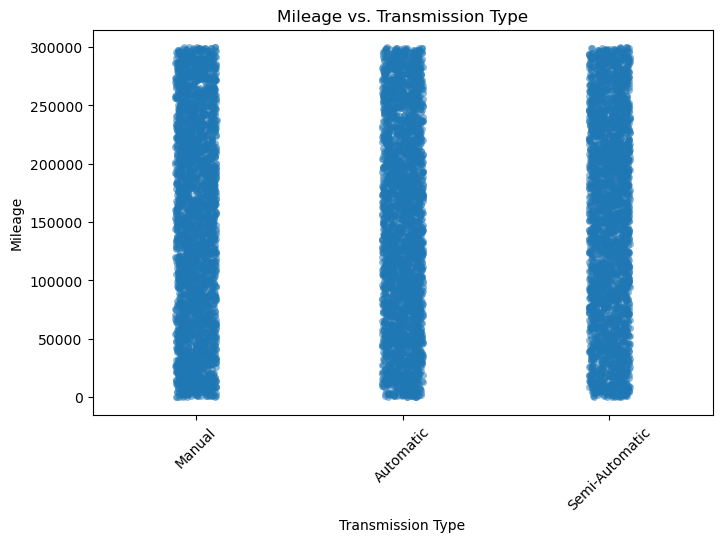

In [71]:
plt.figure(figsize=(8, 5))
sns.stripplot(x=df["Transmission"], y=df["Mileage"], alpha=0.5, jitter=True)
plt.title("Mileage vs. Transmission Type")
plt.xlabel("Transmission Type")
plt.ylabel("Mileage")
plt.xticks(rotation=45) 
plt.show()

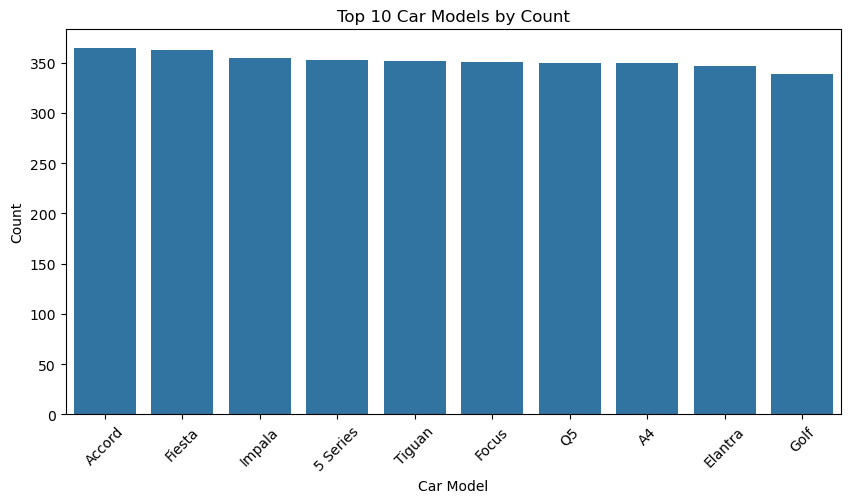

In [72]:
top_models = df["Model"].value_counts().nlargest(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_models.index, y=top_models.values)
plt.title("Top 10 Car Models by Count")
plt.xlabel("Car Model")
plt.ylabel("Count")
plt.xticks(rotation=45)  
plt.show()

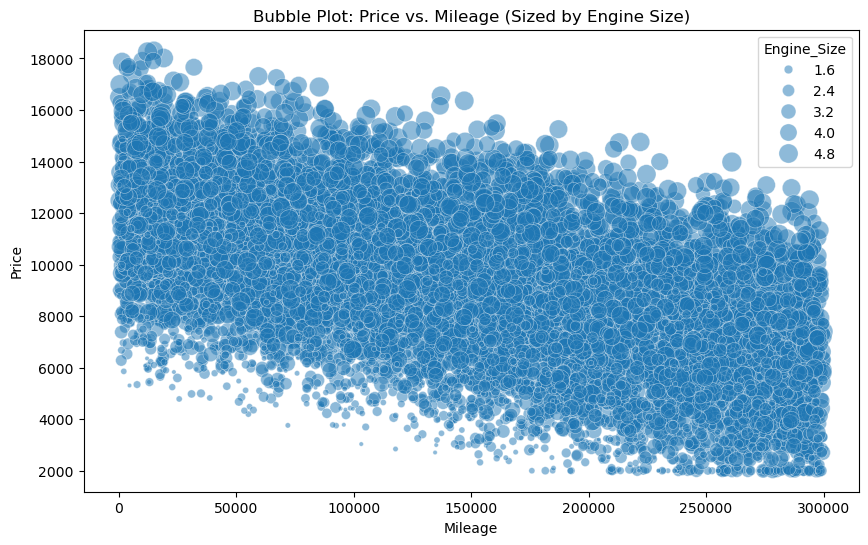

In [73]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["Mileage"], y=df["Price"], size=df["Engine_Size"], sizes=(10, 200), alpha=0.5)
plt.title("Bubble Plot: Price vs. Mileage (Sized by Engine Size)")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

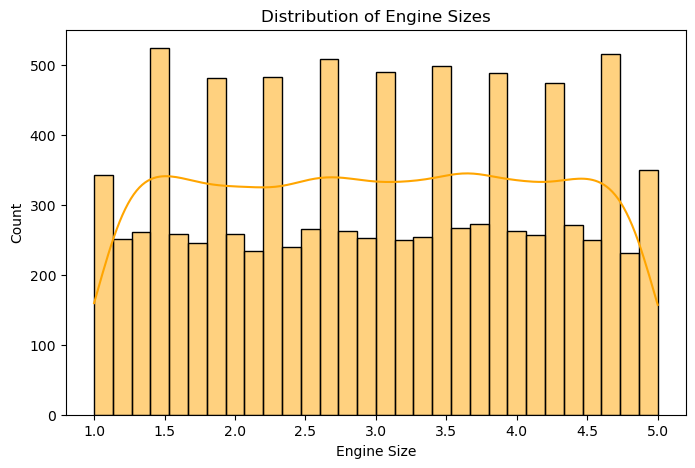

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(df["Engine_Size"], bins=30, kde=True, color="orange")
plt.title("Distribution of Engine Sizes")
plt.xlabel("Engine Size")
plt.ylabel("Count")
plt.show()

This plot, titled "Distribution of Engine Sizes", shows how frequently different engine sizes occur in the dataset.

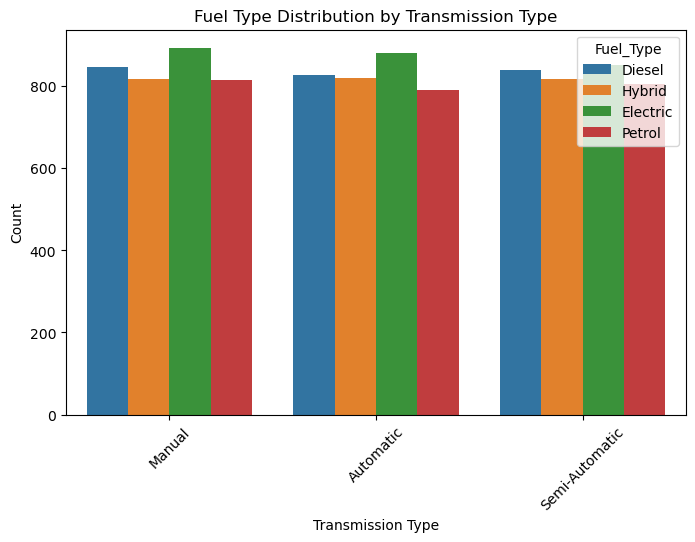

In [75]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df["Transmission"], hue=df["Fuel_Type"])
plt.title("Fuel Type Distribution by Transmission Type")
plt.xlabel("Transmission Type")
plt.ylabel("Count")
plt.xticks(rotation=45) 
plt.show()

The bar chart titled "Fuel Type Distribution by Transmission Type" provides a comparative view of how different fuel types (Diesel, Hybrid, Electric, Petrol) are distributed across three transmission types: Manual, Automatic, and Semi-Automatic.

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.get_dummies(df, columns=['Brand'], prefix='Brand', drop_first=True)
df = pd.get_dummies(df, columns=['Model'], prefix='Model', drop_first=True)
df = pd.get_dummies(df, columns=['Fuel_Type'], prefix='FuelType', drop_first=True)
df = pd.get_dummies(df, columns=['Transmission'], prefix='Transmission', drop_first=True)
X = df.drop(columns=['Price'])
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 4213.92
R² Score: 0.9995


FINAL OBSERVATIONS:
Data Quality & Structure:
-> The dataset is well-structured with key automotive attributes such as Price, Mileage, Engine_Size, Year, Transmission, Fuel_Type, and more.
-> No major issues with missing data; any null values are minimal and manageable.
->Column types are appropriate for analysis and modeling.
Diversity & Balance:
-> The dataset contains a diverse mix of vehicles across brands, models, fuel types, and engine sizes.
-> Distribution of fuel types and transmission types is relatively balanced, which is ideal for training unbiased machine learning models.
Visual Analysis Takeaways:
-> Box plots and violin plots reveal that features like Doors and Owner_Count impact price, though the spread varies.
-> Pairplots and histograms provide early evidence of linear or nonlinear relationships, useful for feature selection in predictive modeling.
Potential for Modeling:
-> This dataset is well-suited for machine learning, especially for:
     Regression (predicting price)
     Classification (predicting fuel type, transmission, or car category)
-> Enough variation and clean structure allow for feature engineering (e.g., Car_Age = Current_Year - Year).

The dataset provides a diverse and balanced range of engine sizes, making this feature highly relevant for modeling price, performance, or fuel consumption. It also supports building models that generalize well across different vehicle segments.